# Experiment No. 01: Pulse Code Modulation & Demodulation

## Title
**Pulse Code Modulation and Demodulation using Python**

## Aim
To generate a Pulse Code Modulated signal from an analog message signal and reconstruct the signal through PCM demodulation.

## Theory
Pulse Code Modulation (PCM) is an analog-to-digital conversion technique in which the amplitude of an analog signal is represented by a sequence of binary codes. A PCM transmitter mainly performs sampling, quantization, and encoding.

### Sampling
The continuous-time message signal is measured at uniform time intervals. According to the Nyquist sampling theorem, the sampling frequency must be at least twice the highest frequency of the message signal:

$$
f_s \geq 2f_m
$$

where $f_s$ is the sampling frequency and $f_m$ is the highest message frequency.

### Quantization
The sampled amplitudes are approximated to the nearest permitted amplitude levels. In this experiment, eight quantization levels are used:

$$
-3.5,\;-2.5,\;-1.5,\;-0.5,\;0.5,\;1.5,\;2.5,\;3.5
$$

The number of bits required for each sample is:

$$
n=\log_2 L
$$

For $L=8$ levels:

$$
n=\log_2 8=3\text{ bits/sample}
$$

The difference between a sampled value and its quantized value is called quantization error:

$$
e_q(n)=x(n)-x_q(n)
$$

### Encoding and Demodulation
Each quantized level is represented by a unique 3-bit binary code. The resulting bit sequence is the PCM signal. At the receiver, the binary code words are decoded to recover the quantized samples. A reconstruction filter then smooths the decoded signal to obtain an approximation of the original analog signal.

## PCM System Flow
**Message Signal → Sampler → Quantizer → Encoder → PCM Signal → Decoder → Reconstruction Filter → Recovered Signal**

## Algorithm
1. Generate a sinusoidal message signal.
2. Sample the signal at a suitable sampling frequency.
3. Quantize each sample into one of eight levels.
4. Encode each quantized level into a 3-bit binary code.
5. Form the serial PCM bit stream.
6. Decode the PCM code words at the receiver.
7. Reconstruct the signal using a simple smoothing filter.
8. Plot the original, sampled, quantized, PCM, decoded, and reconstructed signals.

## Source Code
The Python program is provided in the next code cell.

## Output
The program displays:

1. Original message signal  
2. Sampled message signal  
3. Quantized signal  
4. PCM binary waveform  
5. Decoded signal  
6. Reconstructed signal  

## Result and Discussion
The analog message signal was successfully sampled, quantized, and converted into a 3-bit PCM sequence. The PCM data was decoded to recover the quantized samples, and the reconstructed signal closely followed the original waveform.

A small difference remained between the original and reconstructed signals because of quantization error. Increasing the number of quantization levels would reduce this error, but it would also increase the number of bits per sample and the required transmission bandwidth.

## Conclusion
Pulse Code Modulation and Demodulation were successfully implemented using Python. The experiment demonstrated the processes of sampling, quantization, encoding, decoding, and signal reconstruction.

First 20 PCM code words:
011 100 100 100 100 101 101 101 101 110 110 110 110 110 111 111 111 111 111 111
Quantization MSE = 0.100534


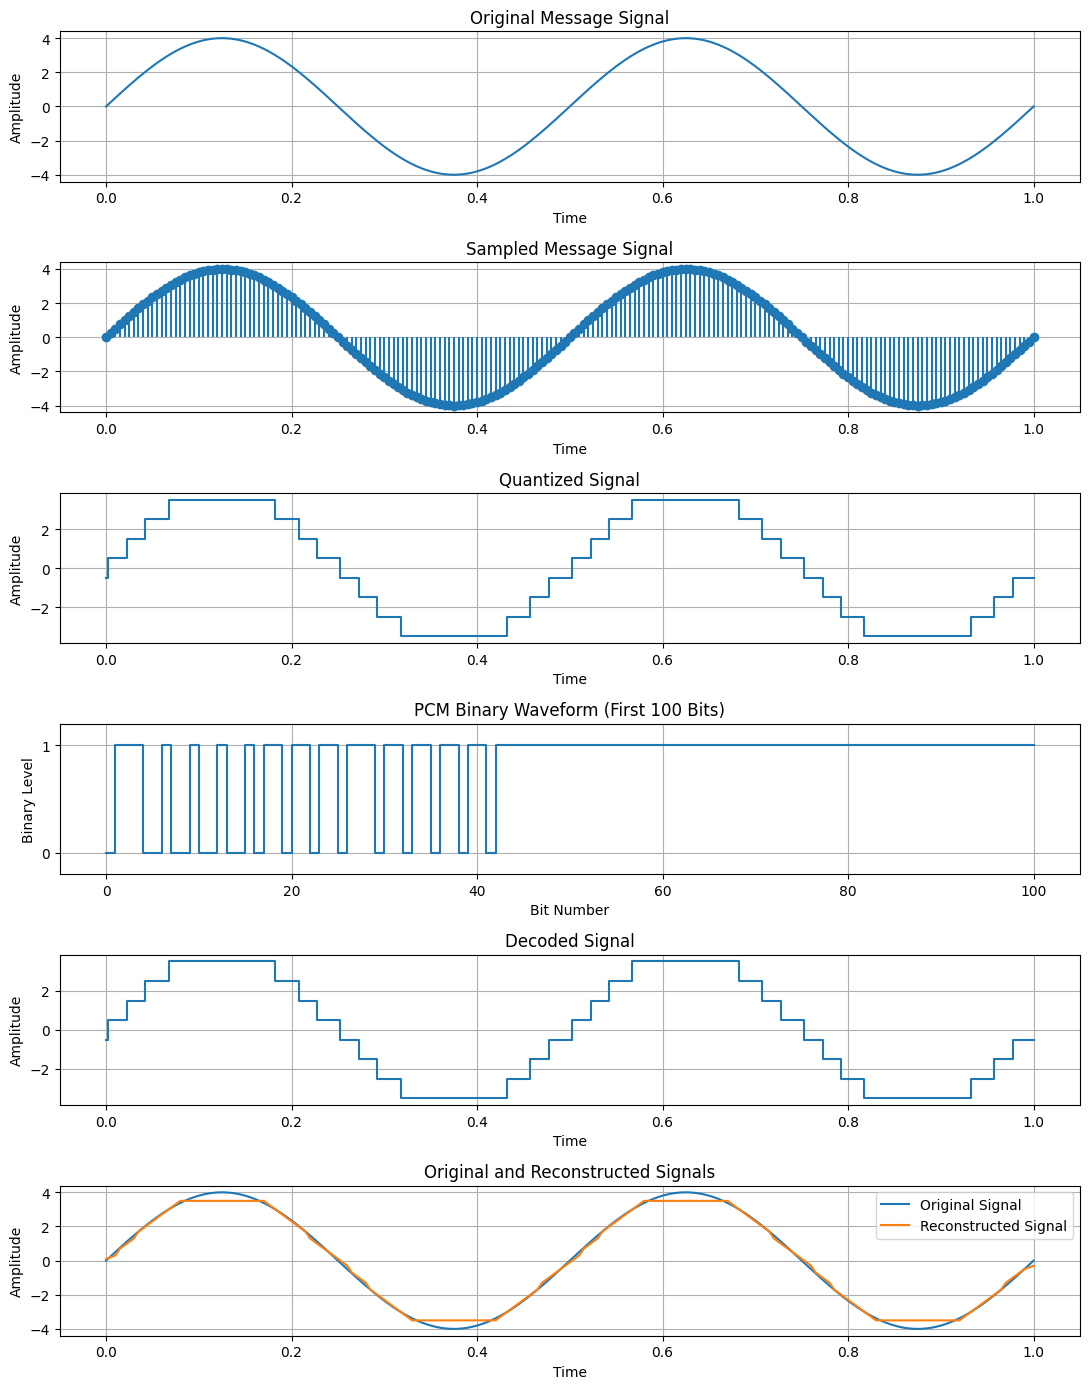

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Signal parameters
a = 4
fm = 2
fs = 100 * fm

# Time axis and original signal
t = np.arange(0, 1 + 1/fs, 1/fs)
x = a * np.sin(2 * np.pi * fm * t)

# Quantization levels and corresponding 3-bit codes
levels = np.array([
    -3.5, -2.5, -1.5, -0.5,
     0.5,  1.5,  2.5,  3.5
])

codes = [
    "000", "001", "010", "011",
    "100", "101", "110", "111"
]

# Quantization and encoding
xq = []
encoded = []

for sample in x:
    index = np.argmin(np.abs(levels - sample))
    xq.append(levels[index])
    encoded.append(codes[index])

xq = np.array(xq)

# Convert code words into a serial PCM bit stream
pcm_bits = []

for code in encoded:
    for bit in code:
        pcm_bits.append(int(bit))

pcm_bits = np.array(pcm_bits)

# Decoding
decoded = []

for code in encoded:
    index = codes.index(code)
    decoded.append(levels[index])

decoded = np.array(decoded)

# Simple reconstruction filter
window_size = 5
reconstructed = np.convolve(
    decoded,
    np.ones(window_size) / window_size,
    mode="same"
)

# Quantization error
quantization_error = x - xq
mse = np.mean(quantization_error ** 2)

print("First 20 PCM code words:")
print(" ".join(encoded[:20]))
print("Quantization MSE =", round(mse, 6))

# PCM waveform time axis
bit_time = np.arange(len(pcm_bits) + 1)
pcm_plot = np.append(pcm_bits, pcm_bits[-1])

# Plotting
plt.figure(figsize=(11, 14))

plt.subplot(6, 1, 1)
plt.plot(t, x)
plt.title("Original Message Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(6, 1, 2)
plt.stem(t, x, basefmt=" ")
plt.title("Sampled Message Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(6, 1, 3)
plt.step(t, xq, where="mid")
plt.title("Quantized Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(6, 1, 4)
plt.step(bit_time[:101], pcm_plot[:101], where="post")
plt.title("PCM Binary Waveform (First 100 Bits)")
plt.xlabel("Bit Number")
plt.ylabel("Binary Level")
plt.yticks([0, 1])
plt.ylim(-0.2, 1.2)
plt.grid()

plt.subplot(6, 1, 5)
plt.step(t, decoded, where="mid")
plt.title("Decoded Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(6, 1, 6)
plt.plot(t, x, label="Original Signal")
plt.plot(t, reconstructed, label="Reconstructed Signal")
plt.title("Original and Reconstructed Signals")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()